# NB04 — Functional Annotation of Enriched OGs (H1 follow-up)

**Goal**: For the 547 anchor-enriched OGs from NB03, pull representative annotations (eggNOG `Description`, `KEGG_ko`, `COG_category`, `Preferred_name`, `PFAMs`, bakta `gene`/`product`) for the gene clusters tagged with each OG. Group by COG functional category and check whether the enriched set falls into the pre-registered functional categories (sporulation revival / anaerobic respiration accessories / mineral attachment EPS / osmoadaptation / anaerobic regulators).

**Inputs**: `data/og_enrichment.tsv`, `data/cohort_og_presence.parquet`, `kbase_ke_pangenome.{eggnog_mapper_annotations, bakta_annotations}`.

**Output**: `data/enriched_ogs_annotated.tsv` (one row per enriched OG with the most-common annotation across its cohort clusters); `figures/h1_functional_categories.png`.

In [1]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from pyspark.sql import functions as F

try:
    spark
except NameError:
    from berdl_notebook_utils.setup_spark_session import get_spark_session
    spark = get_spark_session()

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures'); FIG_DIR.mkdir(exist_ok=True)

enriched = pd.read_csv(DATA_DIR / 'og_enrichment.tsv', sep='\t')
presence = pd.read_parquet(DATA_DIR / 'cohort_og_presence.parquet')
print(f'enriched OGs: {len(enriched)}')

enriched OGs: 547


## 1. Map enriched OGs back to gene clusters in the cohort

In [2]:
enriched_og_set = set(enriched['og_id'].tolist())

# Reuse the full eggNOG annotation pull (all cohort clusters), filter to enriched OGs.
# Re-derive the cluster→OG mapping by re-pulling cluster-level eggNOG data.
cohort = pd.read_csv(DATA_DIR / 'cohort_assignments.tsv', sep='\t')
cohort_genomes = cohort['genome_id'].dropna().unique().tolist()
spark.createDataFrame([(g,) for g in cohort_genomes], ['genome_id']).createOrReplaceTempView('cohort_genomes_v')

ann_df = spark.sql("""
    WITH cohort_clusters AS (
      SELECT DISTINCT j.gene_cluster_id
      FROM kbase_ke_pangenome.gene g
      JOIN kbase_ke_pangenome.gene_genecluster_junction j ON g.gene_id = j.gene_id
      JOIN cohort_genomes_v c ON c.genome_id = g.genome_id
    )
    SELECT a.query_name AS gene_cluster_id, a.eggNOG_OGs, a.KEGG_ko, a.COG_category,
           a.Preferred_name, a.Description, a.PFAMs, a.EC
    FROM kbase_ke_pangenome.eggnog_mapper_annotations a
    JOIN cohort_clusters c ON a.query_name = c.gene_cluster_id
""").toPandas()
print(f'cohort clusters with eggNOG: {len(ann_df)}')

PREFERRED_TAXIDS = ['1239', '2', '1']
def pick_og(s):
    if not s: return None
    by_tax = {}
    for tok in s.split(','):
        m = re.match(r'^([^@]+)@(\d+)\|', tok)
        if m:
            by_tax[m.group(2)] = m.group(1)
    for t in PREFERRED_TAXIDS:
        if t in by_tax:
            return by_tax[t]
    return None
ann_df['og_id'] = ann_df['eggNOG_OGs'].apply(pick_og)
ann_df = ann_df[ann_df['og_id'].isin(enriched_og_set)]
print(f'cohort clusters in enriched OGs: {len(ann_df)}')

cohort clusters with eggNOG: 88245


cohort clusters in enriched OGs: 2911


## 2. Pull bakta annotation per cluster (gene name + product)

In [3]:
cluster_ids = ann_df['gene_cluster_id'].drop_duplicates().tolist()
spark.createDataFrame([(c,) for c in cluster_ids], ['gene_cluster_id']).createOrReplaceTempView('enriched_clusters_v')

bakta_df = spark.sql("""
    SELECT b.gene_cluster_id, b.gene, b.product, b.cog_id, b.cog_category,
           b.kegg_orthology_id, b.uniref50, b.uniref90, b.hypothetical
    FROM kbase_ke_pangenome.bakta_annotations b
    JOIN enriched_clusters_v c ON b.gene_cluster_id = c.gene_cluster_id
""").toPandas()
print(f'bakta annotations for enriched clusters: {len(bakta_df)}')
ann_full = ann_df.merge(bakta_df, on='gene_cluster_id', how='left')

bakta annotations for enriched clusters: 2911


## 3. Per-OG: pick the most-common annotation across its cohort clusters

In [4]:
def mode_or_first(s):
    s = s.dropna().astype(str).replace({'': pd.NA, '-': pd.NA, 'NaN':pd.NA}).dropna()
    if len(s) == 0:
        return None
    return s.mode().iloc[0] if len(s.mode()) else s.iloc[0]

og_ann = (ann_full.groupby('og_id')
          .agg(n_clusters=('gene_cluster_id', 'nunique'),
               cog_category=('COG_category', mode_or_first),
               kegg_ko=('KEGG_ko', mode_or_first),
               preferred_name=('Preferred_name', mode_or_first),
               description=('Description', mode_or_first),
               pfams=('PFAMs', mode_or_first),
               ec=('EC', mode_or_first),
               bakta_gene=('gene', mode_or_first),
               bakta_product=('product', mode_or_first),
               bakta_cog=('cog_id', mode_or_first),
               bakta_uniref50=('uniref50', mode_or_first),
               hypothetical=('hypothetical', lambda x: x.dropna().mean() if x.dropna().size else None))
          .reset_index())
out = enriched.merge(og_ann, on='og_id', how='left')
out_path = DATA_DIR / 'enriched_ogs_annotated.tsv'
out.to_csv(out_path, sep='\t', index=False)
print(f'wrote {len(out)} annotated OGs')
print('\nTop 10 enriched OGs (by p_BH):')
print(out[['og_id','pos_anchor','pos_base','fold_diff','p_BH','preferred_name','description','bakta_product','cog_category']].head(10).to_string(index=False))

wrote 547 annotated OGs

Top 10 enriched OGs (by p_BH):
     og_id  pos_anchor  pos_base  fold_diff     p_BH preferred_name                                 description                                 bakta_product cog_category
     1UIFM           7         0        NaN 0.000383            NaN                  DsrE/DsrF/DrsH-like family                  Peroxiredoxin family protein            S
     1UYVZ           7         0        NaN 0.000383            NaN      Enoyl-(Acyl carrier protein) reductase                  KR domain-containing protein           IQ
     1VDS4           7         0        NaN 0.000383            NaN                            MaoC like domain                 3-hydroxyacyl-ACP dehydratase            I
     1TQFI           9         5  11.160000 0.000514            NaN               CBS domain containing protein                 CBS domain-containing protein            T
     1V0WU           9         5  11.160000 0.000514            NaN               Major F

## 4. COG-category breakdown vs pre-registered functional predictions

=== COG categories in 547 enriched OGs ===
cog_category  n_ogs                      name
           S    130          Function unknown
           C     57         Energy production
           K     50             Transcription
           I     33          Lipid metabolism
           E     30     Amino acid metabolism
           T     29       Signal transduction
           G     22   Carbohydrate metabolism
           P     22   Inorganic ion transport
           M     20        Cell wall/membrane
           Q     18     Secondary metabolites
           L     16           DNA repl/repair
           O     14          Posttransl. mod.
           U     14 Intracellular trafficking
           H     13       Coenzyme metabolism
           N     12             Cell motility


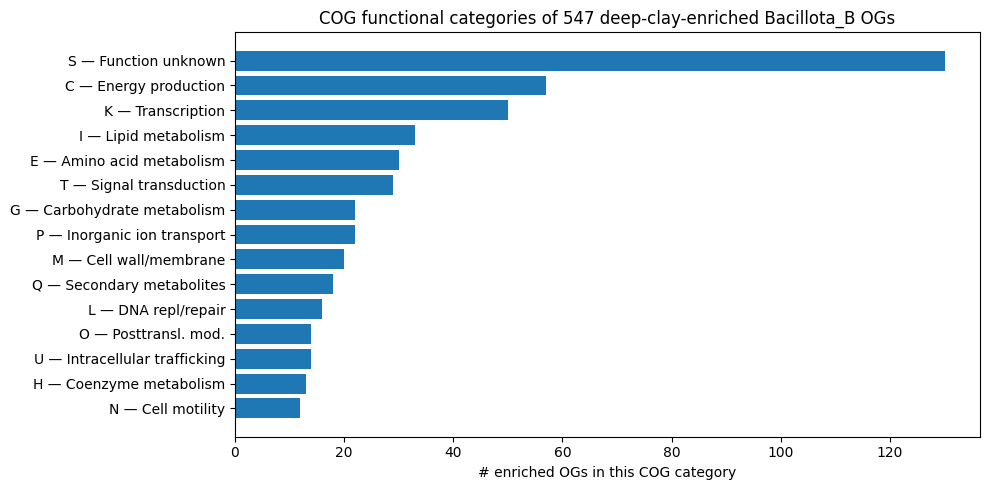

saved: ../figures/h1_functional_categories.png


In [5]:
# COG categories in our enriched set
cogs = []
for c in out['cog_category'].dropna().tolist():
    cogs.extend(list(str(c)))
cog_counts = Counter(cogs)
cog_df = pd.DataFrame(sorted(cog_counts.items(), key=lambda x: -x[1]), columns=['cog_category','n_ogs'])
COG_NAMES = {
    'J':'Translation/ribosome', 'A':'RNA processing', 'K':'Transcription', 'L':'DNA repl/repair',
    'B':'Chromatin', 'D':'Cell cycle/division', 'V':'Defense mechanisms', 'T':'Signal transduction',
    'M':'Cell wall/membrane', 'N':'Cell motility', 'U':'Intracellular trafficking', 'O':'Posttransl. mod.',
    'X':'Mobilome (phage/plasmid/transposon)', 'C':'Energy production', 'G':'Carbohydrate metabolism',
    'E':'Amino acid metabolism', 'F':'Nucleotide metabolism', 'H':'Coenzyme metabolism',
    'I':'Lipid metabolism', 'P':'Inorganic ion transport', 'Q':'Secondary metabolites',
    'R':'General function', 'S':'Function unknown', 'Z':'Cytoskeleton', 'W':'Extracellular structures',
    '-':'unannotated',
}
cog_df['name'] = cog_df['cog_category'].map(COG_NAMES).fillna('?')
print('=== COG categories in 547 enriched OGs ===')
print(cog_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
top = cog_df.head(15)
ax.barh([f"{r.cog_category} — {r['name']}" for _, r in top.iterrows()], top['n_ogs'])
ax.invert_yaxis()
ax.set_xlabel('# enriched OGs in this COG category')
ax.set_title('COG functional categories of 547 deep-clay-enriched Bacillota_B OGs')
plt.tight_layout()
out_fig = FIG_DIR / 'h1_functional_categories.png'
plt.savefig(out_fig, dpi=140, bbox_inches='tight')
plt.show()
print(f'saved: {out_fig}')

## 5. Keyword scan of pre-registered functional categories

In [6]:
# H1 pre-registered categories — keyword scan on bakta_product + eggNOG description + Preferred_name
categories = {
    'sporulation_revival': ['spore', 'sporulation', 'germinat', 'gerA', 'gerB', 'safA', 'cwlJ', 'spoVA', 'cot'],
    'anaerobic_respiration': ['hydrogenas', 'cytochrom', 'sulfite', 'sulfate', 'thiosulfate', 'nitrate', 'nitrite',
                              'fumarate reductase', 'DMSO', 'TMAO', 'oxidoreductase', 'NADH dehydrogenase',
                              'electron transport', 'menaquinone'],
    'mineral_attachment_EPS': ['exopolysaccharide', 'biofilm', 'capsule', 'EPS', 'polysaccharide biosynthesis',
                                'pilin', 'flagell', 'attachment', 'adhesin'],
    'osmoadaptation': ['betaine', 'ectoine', 'osmoprot', 'glycine betaine', 'choline', 'compatible solute',
                       'Na+/H+', 'K+ uptake', 'mechanosensitive'],
    'anaerobic_regulators': ['sigma factor', 'sigF', 'sigE', 'sigK', 'rpoH', 'rpoN', 'two-component',
                              'response regulator', 'anti-sigma', 'redox regulator', 'fnr', 'arcA'],
}

def category_for_row(row):
    text = ' '.join([str(row.get(c) or '') for c in ['preferred_name','description','bakta_product','bakta_gene']]).lower()
    for cat, kws in categories.items():
        if any(kw.lower() in text for kw in kws):
            return cat
    return 'other_or_unannotated'

out['precategory'] = out.apply(category_for_row, axis=1)
print('=== pre-registered category breakdown ===')
print(out['precategory'].value_counts())

# Show example hits in each category
for cat in categories:
    sub = out[out['precategory']==cat].head(8)
    if len(sub) > 0:
        print(f'\n--- {cat} (n={(out["precategory"]==cat).sum()}) ---')
        print(sub[['og_id','pos_anchor','fold_diff','preferred_name','bakta_product']].to_string(index=False))

# Re-save with category column
out.to_csv(DATA_DIR / 'enriched_ogs_annotated.tsv', sep='\t', index=False)
print(f'\nfinal annotated table: {DATA_DIR / "enriched_ogs_annotated.tsv"}')

=== pre-registered category breakdown ===
precategory
other_or_unannotated      462
anaerobic_respiration      42
sporulation_revival        24
mineral_attachment_EPS     12
anaerobic_regulators        4
osmoadaptation              3
Name: count, dtype: int64

--- sporulation_revival (n=24) ---
  og_id  pos_anchor  fold_diff preferred_name                                              bakta_product
COG5577           7  14.466667            NaN                          DUF3231 domain-containing protein
  1VPV7           6  37.200000            NaN                                         Spore coat protein
  1V94H           6  18.600000            NaN                         Stage 0 sporulation A-like protein
  1VDQS           6  12.400000            NaN Bypass of forespore C C-terminal domain-containing protein
  1VDZ7           5  31.000000            NaN                         Stage 0 sporulation A-like protein
  1TSBM           4        NaN            NaN                             